In [1]:
#to avoid Intel Jupyter kernel crash 
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import plotly.express as px
import torch 
import torch.nn as nn
import json
import math

from models import simpleLSTM
from utils import run_closed_loop, perf_measure

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

SMALL_SIZE = 12
MEDIUM_SIZE = 12
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


myFmt_year = mdates.DateFormatter('%Y-%m-%d')
myFmt_month_day_time = mdates.DateFormatter('%m-%d-%H:%M')
myFmt_month_day = mdates.DateFormatter('%m-%d')
myFmt = mdates.DateFormatter('%H:%M')


### Iniztialize and load already trained model

In [2]:
#experiment_path = "./saved_runs/model_with_all_features" #path to default trained model
experiment_path = "./saved_runs/with_pv0.4"
model_name = "best_valid_model.pt"
model_path = os.path.join(experiment_path, model_name)

use_positional_encoding_for_notebook = 'pv_const' #default == 'all'
model = simpleLSTM(n_input_features=5, num_layers=4) #default n_input_features=4
model.load_state_dict(torch.load(model_path,map_location=torch.device("cpu")))

C:\Users\kivi-\AppData\Local\Temp\ipykernel_2580\1039271138.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,map_location=torc

<All keys matched successfully>

### Plot Train and Validation Loss curve, learning rate schedule

In [3]:
history_path = os.path.join(experiment_path, 'train_history.csv')
df_train_history = pd.read_csv(history_path, index_col=0)

fig = px.line(df_train_history, x = 'epoch', y = ['train_loss', 'valid_loss'])
fig.show()

fig = px.line(df_train_history, x = 'epoch', y = ['learning_rate'])
fig.show()

### Scaled testset data for one split (month)


In [21]:
# Read test data
experiment_path = "./saved_runs/with_pv0.4" #default path = model_with_all_features
#experiment_path = "./saved_runs/model_with_all_features"
df_test_scaled_list = []
for i in range(6): #default is 6 but for combined datasets choose 1  
    test_data_path = os.path.join(experiment_path, f'test{i}_data_scaled.csv')
    df_test_scaled = pd.read_csv(test_data_path, index_col = 0)
    # Convert timestamps to datetime objects 
    datetime_index = pd.to_datetime(df_test_scaled.index)
    df_test_scaled.index = datetime_index
    df_test_scaled_list.append(df_test_scaled)
#print(df_test_scaled_list[0],df_test_scaled_list[1])
fig = px.line(df_test_scaled_list[0], x = df_test_scaled.index, y =  df_test_scaled.columns)
fig.show()

df_test_scaled.head()

,NP,sun_altitude,sun_azimuth,irradiance_real,irradiance_fc,pv_size
time,,,,,,
2021-12-15 00:00:00+00:00,0.621218,0.000441,0.016877,0.0,0.0,0.4
2021-12-15 00:15:00+00:00,0.619399,0.003806,0.039064,0.0,0.0,0.4
2021-12-15 00:30:00+00:00,0.625031,0.009718,0.060395,0.0,0.0,0.4
2021-12-15 00:45:00+00:00,0.625230,0.017954,0.080532,0.0,0.0,0.4
2021-12-15 01:00:00+00:00,0.612980,0.028241,0.099283,0.0,0.0,0.4


### Analyze the predictions
In this section we analyze, the performance of the trained demand forecasting algorithm and its effectiveness according to the detection of hurting band linmits. \
We face the scenario of having acces to all historic data. The power $p$, suns altitude $\phi$,  suns azimuth $\theta$, and the original irradiance $\zeta$. \
We have to define the lookback window for initializing the LSTM. This can be either 1hour, 1day, or 2days of the past measurements. For forecasting we use the available forecasts of the irradiance $\zeta_{fc}$. 

In our setting we initialize the LSTM with past data of one day and forecast for the next 24hours. 
The forecasts are used to extract the timepoint and the strenght of the band hurting.

In [14]:
# Read scalings
scaling_data_path = os.path.join(experiment_path,'scalings.json')
with open(scaling_data_path, 'r') as file:
    scaling_dict = json.load(file)

# prepare sclaings to rescale original power profile:
#max_power = scaling_dict['active_power']['max']
#min_power = scaling_dict['active_power']['min']
max_power = scaling_dict['NP']['max']
min_power = scaling_dict['NP']['min']

max_irradiance = scaling_dict['irradiance_real']['max']
min_irradiance = scaling_dict['irradiance_real']['min']

max_irradiance_fc = scaling_dict['irradiance_fc']['max']
min_irradiance_fc = scaling_dict['irradiance_fc']['min']


#months = ['july', 'august', 'september', 'october', 'november', 'december']
months = ['july']
tp_list = []
tn_list = []
fp_list = []
fn_list = []

violation_labels_list = []
violation_predictions_list = []
area_of_harm_labels_list = []
area_of_harm_predictions_list = []
time_of_harm_labels_list = []
time_of_harm_predictions_list = []


for k, month in enumerate(months):
    lookback = 96
    predict_forward = 96
    feed_in_limit = -200
    power_treshold = -200 # -159

    violation_labels = []
    violation_predictions = []

    area_of_harm_prediction = []
    area_of_harm_targets = []

    time_of_harm_prediction = []
    time_of_harm_targets = []

    max_harm_prediction = []
    max_harm_targets = []

    df_test_scaled = df_test_scaled_list[k]
    # Convert timestamps to datetime objects 
    datetime_index = pd.to_datetime(df_test_scaled.index)
    df_test_scaled.index = datetime_index
    # Extract unique days
    unique_days_test = pd.Series(datetime_index).dt.date.unique()

    for i in range(len(unique_days_test)-1):
        df_two_days = df_test_scaled.loc[str(unique_days_test[i]): str(unique_days_test[i+1])]
        predictions = run_closed_loop(model, df_two_days.values, lookback=lookback, future_prediction=predict_forward, use_positional_encoding = use_positional_encoding_for_notebook )
        df_new = pd.DataFrame(columns = ['target', 'prediction', 'delta'])
        df_new['target'] = df_two_days.values[:,0]
        #df_new['index'] = df_new.index
        df_new["irradiance_real"] = df_two_days["irradiance_real"].values
        df_new["irradiance_fc"] = df_two_days["irradiance_fc"].values
        
        df_new.loc[lookback+1:predict_forward+lookback-1, 'prediction'] = predictions
        df_new['prediction'] = df_new['prediction'].fillna(0)
        df_new['target_original'] = df_new['target'] * (max_power - min_power) + min_power # (df_train_val[column] - min_val) / (max_val - min_val)
        df_new['prediction_original'] = df_new['prediction'] * (max_power - min_power) + min_power 
        df_new['irradiance_real_original'] = df_new['irradiance_real'] * (max_irradiance - min_irradiance) + min_irradiance 
        df_new['irradiance_fc_original'] = df_new['irradiance_fc'] * (max_irradiance_fc - min_irradiance_fc) + min_irradiance_fc 

        df_new.index = df_two_days.index

        df_second_day = df_new.iloc[lookback+1::].copy()

        violations_targets_index = df_second_day['target_original'] <= feed_in_limit
        violations_predictions_index = df_second_day['prediction_original'] <= power_treshold # 159 # False negatives verringern, area ofs harms relative klein und zeit kurz, deswegen eher kurz deswegen setzt man das limit runter um sensible anszuschlagen, wenn wir keine Fn haben wollen dannn könnten wir die schwelle runter stellen dann würde es nur zusätzliche 6 

        violation_targets_time = np.sum(violations_targets_index)* 15
        violation_predictions_time = np.sum(violations_predictions_index)* 15
        time_of_harm_targets.append(violation_targets_time)
        time_of_harm_prediction.append(violation_predictions_time)

        violation_targets_sum = np.sum(np.abs(df_second_day[violations_targets_index]['target_original'].values + 200))* 15/60
        violation_predictions_sum = np.sum(np.abs(df_second_day[violations_predictions_index]['prediction_original'].values + 200)) *15/60
        area_of_harm_prediction.append(violation_predictions_sum)
        area_of_harm_targets.append(violation_targets_sum)

        #fig, ax = plt.subplots()
        #ax.plot(df_second_day['target_original'], label = 'target')
        #ax.plot(df_second_day['prediction_original'], label = 'prediction')
        #ax.legend()

        #plt.show()

        max_harm_prediction.append((df_second_day['prediction_original']).min())
        max_harm_targets.append((df_second_day['target_original'].min()))
        #print(violation_targets_values,  'kWh')
        #print(violation_predictions_values, 'kWh')

        #df_new['']
        #print(violations_targets_index)
        #print(violations_predictions_index)

        if (violations_targets_index).any():
            violation_labels.append(1)
        else:
            violation_labels.append(0)

        if (violations_predictions_index).any():
            violation_predictions.append(1)
        else:
            violation_predictions.append(0)
    
    
    #conv_matrix = confusion_matrix(violation_labels, violation_predictions).ravel()
    #print(conv_matrix)
    #tn, fp, fn, tp = conv_matrix.ravel()
    
    (tp, tn, fp, fn) = perf_measure(np.array(violation_labels), np.array(violation_predictions))

    tp_list.append(tp)
    tn_list.append(tn)
    fp_list.append(fp)
    fn_list.append(fn)

    violation_labels_list.append(violation_labels)
    violation_predictions_list.append(violation_predictions)

    area_of_harm_labels_list.append(area_of_harm_targets)
    area_of_harm_predictions_list.append(area_of_harm_prediction)
    time_of_harm_labels_list.append(time_of_harm_targets)
    time_of_harm_predictions_list.append(time_of_harm_prediction)


    print('Month:', month)
    print(f'Number of test days: {len(violation_labels)}')
    print('labels:      ', violation_labels)
    print('prediction:  ', violation_predictions)
    print('area of harm labels[kWh]:      ', area_of_harm_targets)
    print('area of harm prediction[kWh]:  ', area_of_harm_prediction)

    print('max harm labels[kW]:      ', max_harm_targets)
    print('max harm prediction[kW]:  ', max_harm_prediction)

    print('time of harm labels[minutes]:      ', time_of_harm_targets)
    print('time of harm prediction[minutes]:  ', time_of_harm_prediction)

    abs_harm_difference = np.abs(np.array(max_harm_prediction)-np.array(max_harm_targets))
    #print('difference:', abs_harm_difference)
    #print('average_difference:', np.mean(abs_harm_difference))
df_confusion = pd.DataFrame({'month' : months, 'TP' : tp_list,  'TN' : tn_list, 'FP' : fp_list, 'FN' : fn_list})


C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\340985388.py:69: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\340985388.py:69: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\340985388.py:69: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C

Month: july
Number of test days: 14
labels:       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
prediction:   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
area of harm labels[kWh]:       [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
area of harm prediction[kWh]:   [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
max harm labels[kW]:       [np.float64(-109.93856931573336), np.float64(-84.84800214511017), np.float64(-112.51553209389317), np.float64(-110.59836579590059), np.float64(-115.90186592888122), np.float64(-112.0822817920257), np.float64(-111.43982302958547), np.float64(-112.30998381817392), np.float64(-108.53

C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\340985388.py:69: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



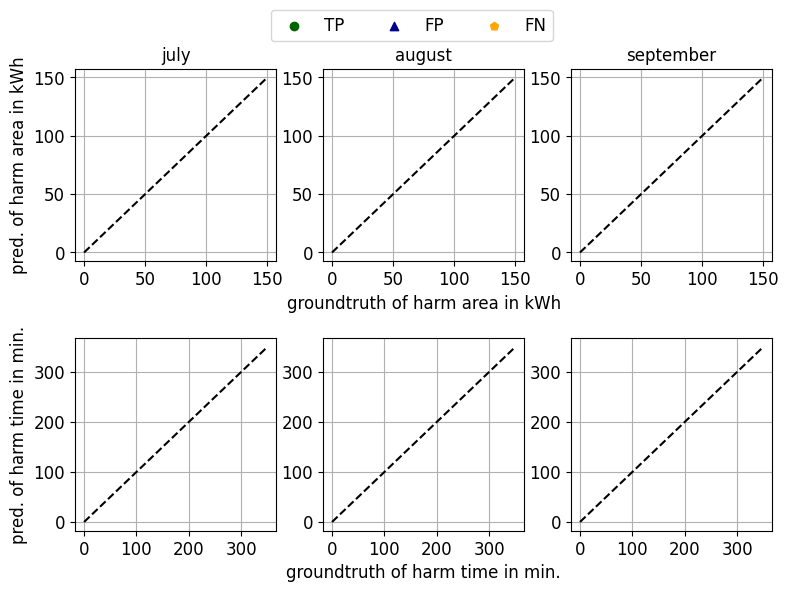

In [8]:
months = ['july', 'august', 'september']

fig, axs = plt.subplots(2,3, figsize= (3*3, 2*3))

for i in range(len(months)):
    month = months[i]
    violation_labels = np.array(violation_labels_list[i])
    violation_predictions = np.array(violation_predictions_list[i])

    area_of_harm_labels = np.array(area_of_harm_labels_list[i])
    area_of_harm_predictions = np.array(area_of_harm_predictions_list[i])

    time_of_harm_labels = np.array(time_of_harm_labels_list[i])
    time_of_harm_predictions = np.array(time_of_harm_predictions_list[i])


    y_actual = violation_labels
    y_pred = violation_predictions
    tp_idx = (y_actual==1) & (y_pred==1)
    #tn = np.sum((y_actual==0) & (y_pred==0))
    fp_idx = (y_actual==0) & (y_pred==1)
    fn_idx = (y_actual==1) & (y_pred==0)

    
    axs[0, i].scatter(area_of_harm_labels[tp_idx], area_of_harm_predictions[tp_idx], label= 'TP', color = 'darkgreen', )
    axs[1, i].scatter(time_of_harm_labels[tp_idx], time_of_harm_predictions[tp_idx], label = 'TP', color = 'darkgreen')

    axs[0, i].scatter(area_of_harm_labels[fp_idx], area_of_harm_predictions[fp_idx], label= 'FP', color = 'darkblue', marker = '^')
    axs[1, i].scatter(time_of_harm_labels[fp_idx], time_of_harm_predictions[fp_idx], label = 'FP', color = 'darkblue', marker = '^')

    axs[0, i].scatter(area_of_harm_labels[fn_idx], area_of_harm_predictions[fn_idx], label= 'FN', color = 'orange', marker = 'p')
    axs[1, i].scatter(time_of_harm_labels[fn_idx], time_of_harm_predictions[fn_idx], label = 'FN', color = 'orange', marker ='p' )
    #axs[0, i].legend()
    #axs[1, i].legend()
    
    if i == 100:
        axs[1, i].plot([0, 40], [0, 40], color = 'black', linestyle='dashed')
        axs[0, i].plot([0, 10], [0, 10], color = 'black', linestyle='dashed')
    else:
        axs[1, i].plot([0, 350], [0, 350], color = 'black', linestyle='dashed')
        axs[0, i].plot([0, 150], [0, 150], color = 'black', linestyle='dashed')

    axs[0, i].grid()
    axs[1, i].grid()

    axs[0,i].set_title(month)

axs[0,1].set_xlabel('groundtruth of harm area in kWh')
axs[1,1].set_xlabel('groundtruth of harm time in min.')

axs[0,0].set_ylabel('pred. of harm area in kWh')
axs[1,0].set_ylabel('pred. of harm time in min.')


plt.subplots_adjust(hspace = 0.4, wspace = 0.23)
axs[0, 1].legend(loc='lower left', bbox_to_anchor=(-0.3,1.1), ncol=3)

plt.savefig("./paper_figures/area_time_of_harm.pdf", bbox_inches='tight')



In [9]:
df_confusion['acc'] = (df_confusion['TP'] + df_confusion['TN']) / (df_confusion['TP'] + df_confusion['TN'] + df_confusion['FP'] + df_confusion['FN'])
df_confusion['precision'] = (df_confusion['TP']) / (df_confusion['TP']+ df_confusion['FP'])
df_confusion['recall'] = (df_confusion['TP']) / (df_confusion['TP']+ df_confusion['FN'])
df_confusion['f1'] = 2 *  df_confusion['precision']*df_confusion['recall']/(df_confusion['precision']+df_confusion['recall'])

df_confusion
#print(df_confusion[['month', 'TP', 'TN', 'FP','FN', 'acc', 'f1']].to_latex(index = False, header= True, float_format="{:.2f}".format))

,month,TP,TN,FP,FN,acc,precision,recall,f1
0,july,0,14,0,0,1.0,NaN,NaN,NaN
1,august,0,14,0,0,1.0,NaN,NaN,NaN
2,september,0,14,0,0,1.0,NaN,NaN,NaN
3,october,0,14,0,0,1.0,NaN,NaN,NaN
4,november,0,14,0,0,1.0,NaN,NaN,NaN
5,december,0,14,0,0,1.0,NaN,NaN,NaN


### Comparison and Analysis of Model train with different input features

In [10]:
# Read Validation Data
#experiment_path = "./saved_runs/model_with_all_features"
experiment_path = "./saved_runs/test_extended_input"
valid_active_power_list = []
for i in range(6):
    valid_data_path = os.path.join(experiment_path, f'test{i}_data_scaled.csv')
    df_valid_scaled = pd.read_csv(valid_data_path, index_col = 0)
    # Convert timestamps to datetime objects 
    datetime_index = pd.to_datetime(df_valid_scaled.index)
    df_valid_scaled.index = datetime_index
    unique_days = pd.Series(datetime_index).dt.date.unique()
    for k in range(len(unique_days)):
        valid_active_power = df_valid_scaled.loc[str(unique_days[k])]['active_power'].values.reshape(1,-1)
        if k ==0:
            valid_active_power_set = valid_active_power
        else:
            valid_active_power_set = np.concatenate((valid_active_power_set, valid_active_power), axis = 0)
    #print(valid_active_power_set.shape)
    valid_active_power_list.append(valid_active_power_set)
    
time_of_one_day = pd.Series(df_valid_scaled.loc[str(unique_days[i+1])].index)
valid_active_power_all = np.array(valid_active_power_list).reshape(-1, 96)
print('all validation day-profiles:', valid_active_power_all.shape)


all validation day-profiles: (90, 96)


In [11]:
experiment_path_list = ["./saved_runs/model_with_no_features", "./saved_runs/model_with_sun_features", "./saved_runs/model_with_all_features","./saved_runs/with_pv1.0", "./saved_runs/model_with_all_features"]
positional_encoding_list = ['none', 'sun', 'all','pv_const','all_original']
input_features_list = [1, 3, 4, 5,4]

#experiment_path_list = ["./saved_runs/model_with_no_features", "./saved_runs/model_with_sun_features", "./saved_runs/model_with_all_features", "./saved_runs/model_with_all_features"]
#positional_encoding_list = ['none', 'sun', 'all', 'all_original']
#input_features_list = [1, 3, 4, 4]

model_predictions = []

for experiment_path,  positional_encoding, n_input_features in zip(experiment_path_list, positional_encoding_list, input_features_list):

    #print('')
    model_name = "best_valid_model.pt"
    model_path = os.path.join(experiment_path, model_name)
    history_path = os.path.join(experiment_path, 'train_history.csv')
    df_train_history = pd.read_csv(history_path, index_col=0)

    print(experiment_path, 'min. train loss:', np.min(df_train_history['train_loss'].values), 'min. val loss:', np.min(df_train_history['valid_loss'].values)  )
    use_positional_encoding = positional_encoding
    model = simpleLSTM(n_input_features=n_input_features, num_layers=4)
    model.load_state_dict(torch.load(model_path,map_location=torch.device("cuda:0")))

    lookback = 96
    predict_forward = 96
    predictions_testset_list = []
    for k, df_test_scaled in enumerate(df_test_scaled_list):
        datetime_index = pd.to_datetime(df_test_scaled.index)
        unique_days_test = pd.Series(datetime_index).dt.date.unique()
        for i in range(len(unique_days_test)-2):
            df_two_days = df_test_scaled.loc[str(unique_days_test[i]): str(unique_days_test[i+1])]
            #print(df_two_days.shape)
            predictions = run_closed_loop(model, df_two_days.values, lookback=lookback, future_prediction=predict_forward, use_positional_encoding = use_positional_encoding)
            predictions = predictions.reshape(1,-1)
            if  i==0: 
                predictions_set = predictions
            else:
                predictions_set = np.concatenate((predictions_set, predictions), axis = 0)
        predictions_testset_list.append(predictions_set)
        print(predictions_set.shape)

    model_predictions.append(predictions_testset_list)
    print(model_predictions)

./saved_runs/model_with_no_features min. train loss: 0.0022766815151831 min. val loss: 0.0017679605332668


C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\1665725520.py:22: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
[[array([[0.5935752 , 0.58351326, 0.5757275 , ..., 0.63012636, 0.6262411 ,
        0.6231565 ],
       [0.5969953 , 0.579526  , 0.5647872 , ..., 0.6633737 , 0.65496105,
        0.6471439 ],
       [0.58863425, 0.5688242 , 0.55231404, ..., 0.6710542 , 0.662595  ,
        0.6543265 ],
       ...,
       [0.5910113 , 0.58129877, 0.5739138 , ..., 0.62640256, 0.6230601 ,
        0.6202517 ],
       [0.59542155, 0.58394104, 0.5758923 , ..., 0.6297381 , 0.6260011 ,
        0.623011  ],
       [0.5845944 , 0.56783533, 0.55380875, ..., 0.6563167 , 0.6483528 ,
        0.64136446]], dtype=float32), array([[0.597433  , 0.58438635, 0.57446456, ..., 0.63736653, 0.63156015,
        0.6270078 ],
       [0.6020315 , 0.59881246, 0.5957659 , ..., 0.6132994 , 0.61215204,
        0.6122537 ],
       [0.59051883, 0.5777702 , 0.56789356, ..., 0.6352624 , 0.6299832 ,
        0.6258828 ],
       ...,
       [0.5882782 , 0.57755053, 0.5686215 , ..., 0.631232

C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\1665725520.py:22: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
[[array([[0.5935752 , 0.58351326, 0.5757275 , ..., 0.63012636, 0.6262411 ,
        0.6231565 ],
       [0.5969953 , 0.579526  , 0.5647872 , ..., 0.6633737 , 0.65496105,
        0.6471439 ],
       [0.58863425, 0.5688242 , 0.55231404, ..., 0.6710542 , 0.662595  ,
        0.6543265 ],
       ...,
       [0.5910113 , 0.58129877, 0.5739138 , ..., 0.62640256, 0.6230601 ,
        0.6202517 ],
       [0.59542155, 0.58394104, 0.5758923 , ..., 0.6297381 , 0.6260011 ,
        0.623011  ],
       [0.5845944 , 0.56783533, 0.55380875, ..., 0.6563167 , 0.6483528 ,
        0.64136446]], dtype=float32), array([[0.597433  , 0.58438635, 0.57446456, ..., 0.63736653, 0.63156015,
        0.6270078 ],
       [0.6020315 , 0.59881246, 0.5957659 , ..., 0.6132994 , 0.61215204,
        0.6122537 ],
       [0.59051883, 0.5777702 , 0.56789356, ..., 0.6352624 , 0.6299832 ,
        0.6258828 ],
       ...,
       [0.5882782 , 0.57755053, 0.5686215 , ..., 0.631232

...

(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
[[array([[0.5935752 , 0.58351326, 0.5757275 , ..., 0.63012636, 0.6262411 ,
        0.6231565 ],
       [0.5969953 , 0.579526  , 0.5647872 , ..., 0.6633737 , 0.65496105,
        0.6471439 ],
       [0.58863425, 0.5688242 , 0.55231404, ..., 0.6710542 , 0.662595  ,
        0.6543265 ],
       ...,
       [0.5910113 , 0.58129877, 0.5739138 , ..., 0.62640256, 0.6230601 ,
        0.6202517 ],
       [0.59542155, 0.58394104, 0.5758923 , ..., 0.6297381 , 0.6260011 ,
        0.623011  ],
       [0.5845944 , 0.56783533, 0.55380875, ..., 0.6563167 , 0.6483528 ,
        0.64136446]], dtype=float32), array([[0.597433  , 0.58438635, 0.57446456, ..., 0.63736653, 0.63156015,
        0.6270078 ],
       [0.6020315 , 0.59881246, 0.5957659 , ..., 0.6132994 , 0.61215204,
        0.6122537 ],
       [0.59051883, 0.5777702 , 0.56789356, ..., 0.6352624 , 0.6299832 ,
        0.6258828 ],
       ...,
       [0.5882782 , 0.57755053, 0.5686215 , ..., 0.631232

C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\1665725520.py:22: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
[[array([[0.5935752 , 0.58351326, 0.5757275 , ..., 0.63012636, 0.6262411 ,
        0.6231565 ],
       [0.5969953 , 0.579526  , 0.5647872 , ..., 0.6633737 , 0.65496105,
        0.6471439 ],
       [0.58863425, 0.5688242 , 0.55231404, ..., 0.6710542 , 0.662595  ,
        0.6543265 ],
       ...,
       [0.5910113 , 0.58129877, 0.5739138 , ..., 0.62640256, 0.6230601 ,
        0.6202517 ],
       [0.59542155, 0.58394104, 0.5758923 , ..., 0.6297381 , 0.6260011 ,
        0.623011  ],
       [0.5845944 , 0.56783533, 0.55380875, ..., 0.6563167 , 0.6483528 ,
        0.64136446]], dtype=float32), array([[0.597433  , 0.58438635, 0.57446456, ..., 0.63736653, 0.63156015,
        0.6270078 ],
       [0.6020315 , 0.59881246, 0.5957659 , ..., 0.6132994 , 0.61215204,
        0.6122537 ],
       [0.59051883, 0.5777702 , 0.56789356, ..., 0.6352624 , 0.6299832 ,
        0.6258828 ],
       ...,
       [0.5882782 , 0.57755053, 0.5686215 , ..., 0.631232

C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\1665725520.py:22: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
(13, 95)
[[array([[0.5935752 , 0.58351326, 0.5757275 , ..., 0.63012636, 0.6262411 ,
        0.6231565 ],
       [0.5969953 , 0.579526  , 0.5647872 , ..., 0.6633737 , 0.65496105,
        0.6471439 ],
       [0.58863425, 0.5688242 , 0.55231404, ..., 0.6710542 , 0.662595  ,
        0.6543265 ],
       ...,
       [0.5910113 , 0.58129877, 0.5739138 , ..., 0.62640256, 0.6230601 ,
        0.6202517 ],
       [0.59542155, 0.58394104, 0.5758923 , ..., 0.6297381 , 0.6260011 ,
        0.623011  ],
       [0.5845944 , 0.56783533, 0.55380875, ..., 0.6563167 , 0.6483528 ,
        0.64136446]], dtype=float32), array([[0.597433  , 0.58438635, 0.57446456, ..., 0.63736653, 0.63156015,
        0.6270078 ],
       [0.6020315 , 0.59881246, 0.5957659 , ..., 0.6132994 , 0.61215204,
        0.6122537 ],
       [0.59051883, 0.5777702 , 0.56789356, ..., 0.6352624 , 0.6299832 ,
        0.6258828 ],
       ...,
       [0.5882782 , 0.57755053, 0.5686215 , ..., 0.631232

none
sun
all
pv_const


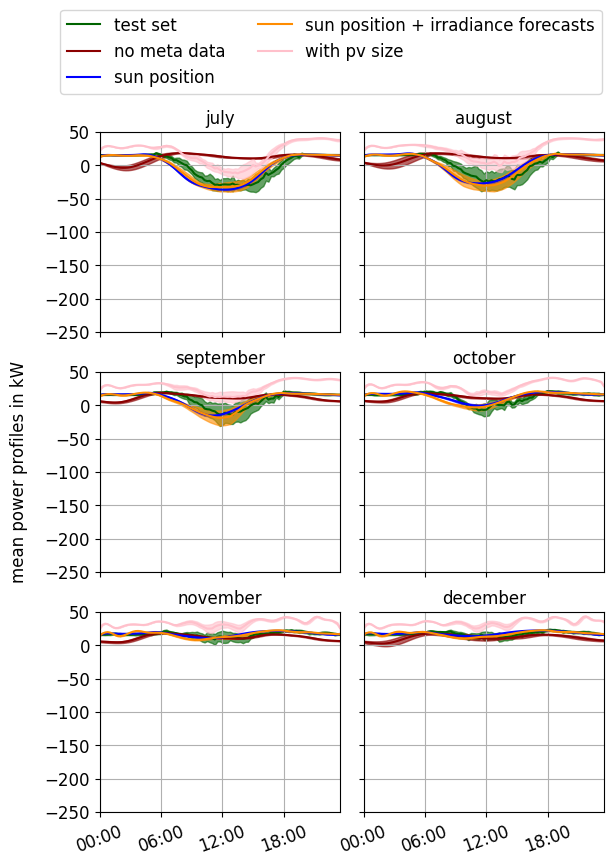

In [12]:
# Plot for comparing the model predictions on the test set with the different scenarion compared to the validation mean power profile
fig, axs = plt.subplots(3,2,  figsize = (6.5,5*2))

colors = ['darkred', 'blue', 'darkorange','pink']
#colors = ['darkorange', 'darkred','blue']
months = ['july', 'august', 'september', 'october', 'november', 'december']
labels = ['no meta data', 'sun position', 'sun position + irradiance forecasts','with pv size']

for i, (ax, valid_active_power) in enumerate(zip(axs.reshape(-1), valid_active_power_list)):
    valid_active_power = valid_active_power* (max_power - min_power) + min_power #Rescale validation power 

    mean_active_power_valid = np.mean(valid_active_power, axis = 0)
    std_active_power_valid = np.std(valid_active_power, axis = 0)

    #ax.set_ylim([0.05, 0.85])
    ax.set_ylim([-250, 50])
    ax.plot(time_of_one_day[0:-1], mean_active_power_valid[0:-1], label = 'test set', color = 'darkgreen')
    ax.fill_between(time_of_one_day[0:-1], mean_active_power_valid[0:-1]-std_active_power_valid[0:-1], mean_active_power_valid[0:-1]+std_active_power_valid[0:-1],  alpha=0.6, color = 'darkgreen')

for i, (encoding, prediction, color) in enumerate(zip(positional_encoding_list, model_predictions, colors)):
    print(encoding)
    label = labels[i]
    for j, (ax,pred) in enumerate(zip(axs.reshape(-1),prediction)):
        #print(pred.shape)
        pred = pred * (max_power - min_power) + min_power #Rescale to orignal values
        mean_active_power_test = np.mean(pred, axis = 0)
        std_active_power_test = np.std(pred, axis = 0)
        ax.fill_between(time_of_one_day[0:-1], mean_active_power_test-std_active_power_test, mean_active_power_test+std_active_power_test,  alpha=0.6, color = color) #color = 'darkgreen'
        ax.plot(time_of_one_day[0:-1],mean_active_power_test, label =label, color = color)

axs[0,0].legend(loc='lower left', bbox_to_anchor=(-0.2, 1.15), ncol=2)
axs[1,0].set_ylabel('mean power profiles in kW')
axs[1,0].yaxis.set_label_coords(-.3, 0.5)

axs[0,1].set_yticklabels([])
#axs[0,2].set_yticklabels([])
axs[1,1].set_yticklabels([])
#axs[1,2].set_yticklabels([])
axs[2,1].set_yticklabels([])


for i, ax in enumerate(axs.reshape(-1)):
    ax.grid()
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_title(months[i])
    ax.set_xlim([time_of_one_day.values[0], time_of_one_day.values[-2]])
    plt.gcf().autofmt_xdate(rotation = 20, ha='center')

plt.subplots_adjust(wspace = 0.1)
plt.savefig("./paper_figures/testset_vs_forecasts_monthly_basis.pdf", bbox_inches='tight')


### Midterm-forcasting comparison 
Between irradiance forecasts and (imaginary result of having the original irradiance)

In [7]:
months = ['july', 'august', 'september', 'october', 'november', 'december']

MAE_list_original_irradiance = []
RMSE_list_original_irradiance = []

MAE_list_forecast_irradiance = []
RMSE_list_forecast_irradiance  = []

for i in range(6):
    lookback = 96
    test_values = df_test_scaled_list[i].values
    num_test_samples = test_values.shape[0]
    steps2predict = num_test_samples-lookback

    groundtruth = test_values[lookback+1::, 0] # There is a + 1 shift in the inference loop
    #groundtruth = test_values[lookback:-1, 0] 
    time = pd.Series(df_test_scaled_list[i].index)[lookback:-1]
    predictions_with_irradiance_fc = run_closed_loop(model, test_values, lookback=lookback, future_prediction=steps2predict, use_positional_encoding='pv_const')
    predictions_with_irradiance_original = run_closed_loop(model, test_values, lookback=lookback, future_prediction=steps2predict, use_positional_encoding='all_original')
    #added pv_const
    #predictions_with_pv_const = run_closed_loop(model, test_values, lookback=lookback, future_prediction=steps2predict, use_positional_encoding='pv_const')

    groundtruth = groundtruth * (max_power - min_power) + min_power #Rescale to orignal values
    predictions_with_irradiance_fc = predictions_with_irradiance_fc * (max_power - min_power) + min_power #Rescale to orignal values
    predictions_with_irradiance_original = predictions_with_irradiance_original * (max_power - min_power) + min_power #Rescale to orignal values

    fig, ax = plt.subplots(2,1, figsize=(8, 4))

    visualization_idx_start = 0
    visualization_idx_stop = visualization_idx_start + 96*14

    #print(visualization_idx_stop)
    #print(predictions_with_irradiance_fc.shape)

    ax[0].plot(time[visualization_idx_start:visualization_idx_stop], groundtruth[visualization_idx_start:visualization_idx_stop], label = 'target', color = 'darkred', zorder = 0)
    ax[0].plot(time[visualization_idx_start:visualization_idx_stop], predictions_with_irradiance_fc[visualization_idx_start:visualization_idx_stop], label = 'prediction with forecasted irradiance',linestyle = '--', color = 'darkblue', zorder = 1)

    ax[0].set_ylabel('power in kW')
    ax[0].legend()
    ax[0].grid()
    ax[0].xaxis.set_major_formatter(myFmt_month_day)
    ax[0].set_xlim([time[visualization_idx_start:visualization_idx_stop].values[0], time[visualization_idx_start:visualization_idx_stop].values[-1]])

    ax[0].legend(loc='lower right', bbox_to_anchor=(1, 1.01), ncol=2)

    squared_error_forecast = (predictions_with_irradiance_fc-groundtruth)**2
    squared_error_original = (predictions_with_irradiance_original-groundtruth)**2
    absolute_error_forecast = np.abs(groundtruth - predictions_with_irradiance_fc)
    absolute_error_original = np.abs(groundtruth - predictions_with_irradiance_original)

    absolute_percentage_eror_forecast = np.abs((groundtruth - predictions_with_irradiance_fc)/groundtruth)
    absolute_percentage_eror_original = np.abs((groundtruth - predictions_with_irradiance_original)/groundtruth)

    ax[1].plot(time[visualization_idx_start:visualization_idx_stop], absolute_error_forecast[visualization_idx_start:visualization_idx_stop], label = 'error(forecasted irradiance, groundtruth)', linestyle = '--', color = 'gray')
    ax[1].plot(time[visualization_idx_start:visualization_idx_stop], absolute_error_original[visualization_idx_start:visualization_idx_stop], label = 'error(original irradiance, groundtruth)', color = 'black')

    #ax[1].plot(time[visualization_idx_start:visualization_idx_stop],  np.ones(len(time[visualization_idx_start:visualization_idx_stop].values)) * squared_error_forecast[visualization_idx_start:visualization_idx_stop].mean(), label = 'MSE', color = 'violet')
    
    
    
    #ax[1].legend()
    ax[1].legend(loc='upper right', bbox_to_anchor=(1, 1), ncol=1)
    ax[1].grid()
    ax[1].set_ylabel('absolute error in kW', labelpad=11)
    ax[1].xaxis.set_major_formatter(myFmt_month_day)
    ax[1].set_xlim([time[visualization_idx_start:visualization_idx_stop].values[0], time[visualization_idx_start:visualization_idx_stop].values[-1]])
    #ax[0].plot(time, groundtruth, label = 'target')

    plt.savefig(f"./paper_figures/mid_term_forecast_{months[i]}.pdf", bbox_inches='tight')
    #tikzplotlib.save(f"./paper_figures/mid_term_forecast_comparison.tex")

    mse_original_irradiance = squared_error_original.mean()
    mse_forecast_irradiance = squared_error_forecast.mean()

    mae_original_irradiance = absolute_error_original.mean()
    mae_forecast_irradiance = absolute_error_forecast.mean()

    rmse_original_irradiance = math.sqrt(mse_original_irradiance)
    #rmse_original_irradiance = mse_original_irradiance
    rmse_forecast_irradiance = math.sqrt(mse_forecast_irradiance)
    #rmse_forecast_irradiance = mse_forecast_irradiance

    print('RMSE with irradiance original:', rmse_original_irradiance) 
    print('RMSE with irradiance fc:', rmse_forecast_irradiance)
    print('MAE with irradiance original:', mae_original_irradiance) 
    print('MAE with irradiance fc:', mae_forecast_irradiance)

    MAE_list_original_irradiance.append(mae_original_irradiance)
    RMSE_list_original_irradiance.append(rmse_original_irradiance)

    MAE_list_forecast_irradiance.append(mae_forecast_irradiance)
    RMSE_list_forecast_irradiance.append(rmse_forecast_irradiance)
    #print(f'MSE increases due to uncertainty of irradiance by: {mse_forecast_irradiance/mse_original_irradiance}')

KeyboardInterrupt: 

### RMSE and MAE Analysis on a monthly basis

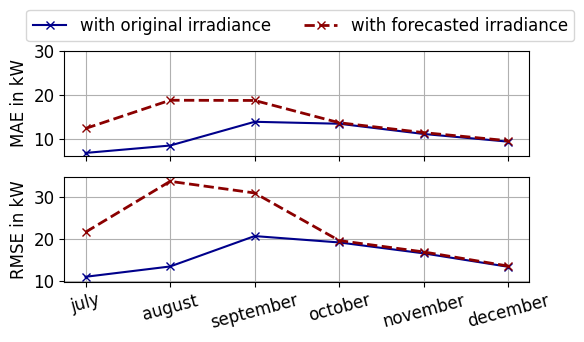

In [29]:
import warnings
warnings.filterwarnings("ignore")
fig, ax = plt.subplots(2,1, figsize=(6, 3))

ax[0].plot(np.arange(6), MAE_list_original_irradiance, label = 'with original irradiance', marker='x', color = 'darkblue')
ax[0].plot(np.arange(6), MAE_list_forecast_irradiance, label = 'with forecasted irradiance', marker='x', linestyle = '--', linewidth=2, color = 'darkred')

ax[0].set_ylabel('MAE in kW')
ax[1].plot(np.arange(1,7), RMSE_list_original_irradiance, label = 'with original irradiance', marker='x',  color = 'darkblue')
ax[1].plot(np.arange(1,7), RMSE_list_forecast_irradiance, label = 'with forecasted irraidance', marker='x', linestyle = '--', linewidth=2, color = 'darkred')
ax[1].set_ylabel('RMSE in kW')

ax[0].set_xticklabels([])
ax[1].set_xticklabels(['dummy', 'july', 'august', 'september', 'october', 'november', 'december'], rotation = 15)

ax[1].set_yticks([10, 20, 30])
#ax[1].set_yticks([0.025, 0.05, 0.075, 0.1])
ax[0].set_yticks([10, 20, 30])

ax[0].legend(loc='lower left', bbox_to_anchor=(-0.1, 1.01), ncol=2)
#ax[1].legend()
ax[0].grid()
ax[1].grid()

plt.savefig("./paper_figures/RMSE_MAE_monthly_basis.pdf", bbox_inches='tight')

### Computational requirements analysis 

In [5]:
class simpleLSTM_2(nn.Module):
    def __init__(self, n_input_features = 4, n_hidden = 50, num_layers = 4, n_outputs = 1, batch_first = True, bidirectional = False):
        super().__init__()
        self.batch_first = batch_first
        self.bidirectional = bidirectional
        #n_input_features = 4
        #n_hidden = 50
        # LSTM Layer
        #self.cnn = nn.Conv1d(in_channels = n_features, out_channels=n_features, kernel_size=18, padding='same')
        self.rnn = nn.LSTM( n_input_features,
                            n_hidden,
                            num_layers,
                            batch_first=self.batch_first, 
                            bidirectional = bidirectional)
        #self.rnn = CfC(n_features, n_hidden, batch_first=False)
        if self.bidirectional:
            self.linear = nn.Linear(n_hidden*2, n_outputs)
        else:
            self.linear = nn.Linear(n_hidden, n_outputs)


    def forward(self, x, hx=None, cx=None):
        #print('input_lstm:', x.shape)
        x, hx = self.rnn(x, hx)  # hx is the hidden state of the RNN
        #x = x[:, -1, :] # Batch_first = True
        #if self.bidirectional:
            #print(x.shape)
            #x = x.view(200, -1, num_directions, hidden_size
        #print('output_lstm:', x.shape)
        x = x[:, -1, :] # Batch_first = False

        x = self.linear(x)
        #print(x.shape)
        return x, hx

In [8]:
import torch
from thop import profile
device = torch.device('cpu')

input_features = 4
model = simpleLSTM_2(n_input_features=input_features, num_layers=4, batch_first = True)
model.to(device)

steps =  1# on step prediction
#steps = int(14*24*60/15) # for 14 days --- 14 days x 24hours x 60 minutes per hour / 15 minutes resolution

print('Computational requirements:')
print('NUCLEO-L432KC@80MHz (ARM Cortex M4) -  RAM:640kB FLASH:2MB -- ~12M MACs/s')
print(f'predicted time steps: {steps}')

input = torch.randn(1, steps+1, input_features)
#print('generated input_shape', input.shape)
total_macs, total_parameters = profile(model, inputs=(input, ) , verbose=False)
print('MACs', int(total_macs))
print('total_parameters', int(total_parameters))

# Lets consider the Edge Device Deployment on an MCU platform with a Floating Point Unit:
# 1 paramerter is stored with 4 Bytes
#  NUCLEO-L432KC@80MHz (ARM Cortex M4) -  RAM:640kB FLASH:2MB -- 12.16M MACs/s
MACs_per_second = 12*1e6
KBFlash = (total_parameters * 4) / 1024

print('Latency in s:', total_macs/MACs_per_second)
print('Stoarge needed for deployment in kB:', KBFlash)

Computational requirements:
NUCLEO-L432KC@80MHz (ARM Cortex M4) -  RAM:640kB FLASH:2MB -- ~12M MACs/s
predicted time steps: 1
MACs 148050
total_parameters 72451
Latency in s: 0.0123375
Stoarge needed for deployment in kB: 283.01171875


### RMSE comparison between old dataset and new constant pv 

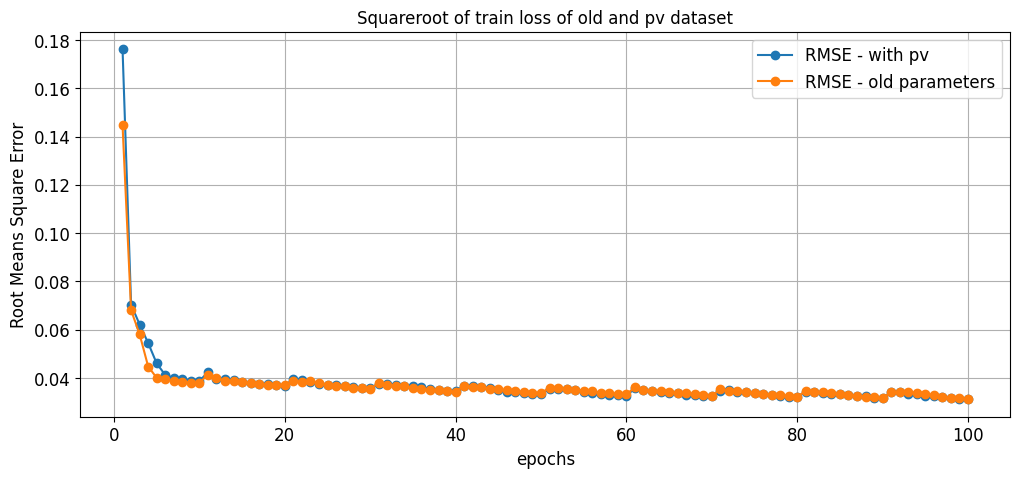

<Figure size 640x480 with 0 Axes>

In [62]:
path_fifth_input = "./saved_runs/test_extended_input/train_history.csv"
path_old_dataset = "./saved_runs/model_with_all_features/train_history.csv"

#creating dataframes
df1 = pd.read_csv(path_fifth_input)
df2 = pd.read_csv(path_old_dataset)

#changing mse to rmse
df1["train_loss_sqrt"] = np.sqrt(df1["train_loss"])
df2["train_loss_sqrt"] = np.sqrt(df2["train_loss"])

#plotting
plt.figure(figsize=(12, 5))
plt.plot(df1["epoch"], df1["train_loss_sqrt"], label="RMSE - with pv", linestyle='-', marker='o')
plt.plot(df2["epoch"], df2["train_loss_sqrt"], label="RMSE - old parameters", linestyle='-', marker='o')

plt.xlabel("epochs")
plt.ylabel("Root Means Square Error")
plt.title("Squareroot of train loss of old and pv dataset")
plt.legend()
plt.grid(True)

plt.show()
plt.savefig("./paper_figures/RMSE_Comparison_PV.pdf", bbox_inches='tight')



### 14 Day Forecast with pv models for 1 month

C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\1669156664.py:8: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Groudtruth [0.61782822 0.61714258 0.60386691 ... 0.63634419 0.63366457 0.61820253]
(1343,)
predictions: [0.70746386 0.7153691  0.72879875 ... 0.8527689  0.8450587  0.83720887]
(1343,)


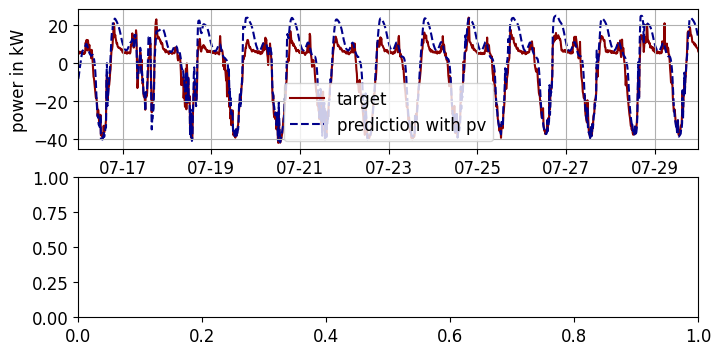

In [24]:
#Path of the model you want to compare
experiment_path = "./saved_runs/with_combined_pv_sizes"

#initializing the model
model_name = "best_valid_model.pt"
model_path = os.path.join(experiment_path, model_name)
model = simpleLSTM(n_input_features=5, num_layers=4) #default n_input_features=4
model.load_state_dict(torch.load(model_path,map_location=torch.device("cpu")))

#getting the scaling of first model
scaling_data_path = os.path.join(experiment_path,'scalings.json')
with open(scaling_data_path, 'r') as file:
    scaling_dict = json.load(file)

#initializing the test data of the model you want to compare the first to
experiment_path_to_compare = "./saved_runs/with_pv0.4"
#getting the specific scalings
scaling_data_path_to_compare = os.path.join(experiment_path_to_compare,'scalings.json')
with open(scaling_data_path_to_compare, 'r') as file:
    scaling_dict_to_compare = json.load(file)

#loading the test data
df_test_scaled_list = []
for i in range(6): #default is 6 but for combined datasets choose 1  
    test_data_path = os.path.join(experiment_path_to_compare, f'test{i}_data_scaled.csv')
    df_test_scaled = pd.read_csv(test_data_path, index_col = 0)
    # Convert timestamps to datetime objects 
    datetime_index = pd.to_datetime(df_test_scaled.index)
    df_test_scaled.index = datetime_index
    df_test_scaled_list.append(df_test_scaled)

    
lookback = 96 #24 hours
#lookback = 288 # 24 hours for combined datasets
test_values = df_test_scaled_list[0].values #index 0 for first month (july)
scaling_dict_testset = test_values[0]
num_test_samples = test_values.shape[0]
steps2predict = num_test_samples-lookback


max_power_model = scaling_dict['NP']['max']
min_power_model = scaling_dict['NP']['min']

max_power_testset = scaling_dict_to_compare['NP']['max']
min_power_testset = scaling_dict_to_compare['NP']['min']

groundtruth = test_values[lookback+1::, 0] # There is a + 1 shift in the inference loop
print("Groudtruth", groundtruth)
print(groundtruth.shape)
time = pd.Series(df_test_scaled_list[0].index)[lookback:-1]

predictions_with_pv = run_closed_loop(model, test_values, lookback = lookback, future_prediction= steps2predict, use_positional_encoding="pv_const")
print("predictions:",predictions_with_pv)
print(predictions_with_pv.shape)

#Rescaling to original values
groundtruth = groundtruth * (max_power_testset - min_power_testset) + min_power_testset 
predictions_with_pv = predictions_with_pv * (max_power_model - min_power_model) + min_power_model 


fig, ax = plt.subplots(2,1, figsize=(8, 4))

visualization_idx_start = 0
visualization_idx_stop = visualization_idx_start + 96*14

#visualization_idx_stop_combined = visualization_idx_start + 288*14

ax[0].plot(time[visualization_idx_start:visualization_idx_stop], groundtruth[visualization_idx_start:visualization_idx_stop], label = 'target', color = 'darkred', zorder = 0)
ax[0].plot(time[visualization_idx_start:visualization_idx_stop], predictions_with_pv[visualization_idx_start:visualization_idx_stop], label = 'prediction with pv',linestyle = '--', color = 'darkblue', zorder = 1)

ax[0].set_ylabel('power in kW')
ax[0].legend()
ax[0].grid()
ax[0].xaxis.set_major_formatter(myFmt_month_day)
ax[0].set_xlim([time[visualization_idx_start:visualization_idx_stop].values[0], time[visualization_idx_start:visualization_idx_stop].values[-1]])

#ax[0].legend(loc='lower right', bbox_to_anchor=(1, 1.01), ncol=2)

#squared_error_forecast = (predictions_with_pv-groundtruth)**2

#absolute_error_forecast = np.abs(groundtruth - predictions_with_pv)


#absolute_percentage_eror_forecast = np.abs((groundtruth - predictions_with_pv)/groundtruth)


#ax[1].plot(time[visualization_idx_start:visualization_idx_stop], absolute_error_forecast[visualization_idx_start:visualization_idx_stop], label = 'error(forecasted power, groundtruth)', linestyle = '--', color = 'gray')


    #ax[1].plot(time[visualization_idx_start:visualization_idx_stop],  np.ones(len(time[visualization_idx_start:visualization_idx_stop].values)) * squared_error_forecast[visualization_idx_start:visualization_idx_stop].mean(), label = 'MSE', color = 'violet')
    
    
"""
ax[1].legend()
ax[1].legend(loc='upper right', bbox_to_anchor=(1, 1), ncol=1)
ax[1].grid()
ax[1].set_ylabel('absolute error in kW', labelpad=11)
ax[1].xaxis.set_major_formatter(myFmt_month_day)
ax[1].set_xlim([time[visualization_idx_start:visualization_idx_stop].values[0], time[visualization_idx_start:visualization_idx_stop].values[-1]])
ax[0].plot(time, groundtruth, label = 'target')
"""
plt.savefig(f"./paper_figures/14_day_forecast_0.2.pdf", bbox_inches='tight')


### Plot of 3 pv preditions each seperatedly trained


In [ ]:
path02="./saved_runs/with_pv0.2"
path04 = "./saved_runs/with_pv0.4"
path06 = "./saved_runs/with_pv0.6"
path08 = "./saved_runs/with_pv0.8"
path10 = "./saved_runs/with_pv1.0"

model_name = "best_valid_model.pt"

model02_path = os.path.join(path02, model_name)
model02 = simpleLSTM(n_input_features=5, num_layers=4) #default n_input_features=4
model02.load_state_dict(torch.load(model02_path,map_location=torch.device("cpu")))

model04_path = os.path.join(path04, model_name)
model04 = simpleLSTM(n_input_features=5, num_layers=4) #default n_input_features=4
model04.load_state_dict(torch.load(model04_path,map_location=torch.device("cpu")))

model06_path = os.path.join(path06, model_name)
model06 = simpleLSTM(n_input_features=5, num_layers=4) #default n_input_features=4
model06.load_state_dict(torch.load(model06_path,map_location=torch.device("cpu")))

model08_path = os.path.join(path08, model_name)
model08 = simpleLSTM(n_input_features=5, num_layers=4) #default n_input_features=4
model08.load_state_dict(torch.load(model08_path,map_location=torch.device("cpu")))

model10_path = os.path.join(path10, model_name)
model10 = simpleLSTM(n_input_features=5, num_layers=4) #default n_input_features=4
model10.load_state_dict(torch.load(model10_path,map_location=torch.device("cpu")))


predictions_with_pv02 = run_closed_loop(model02, test_values, lookback = lookback, future_prediction= steps2predict, use_positional_encoding="pv_const")


C:\Users\kivi-\AppData\Local\Temp\ipykernel_19000\1322732590.py:8: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



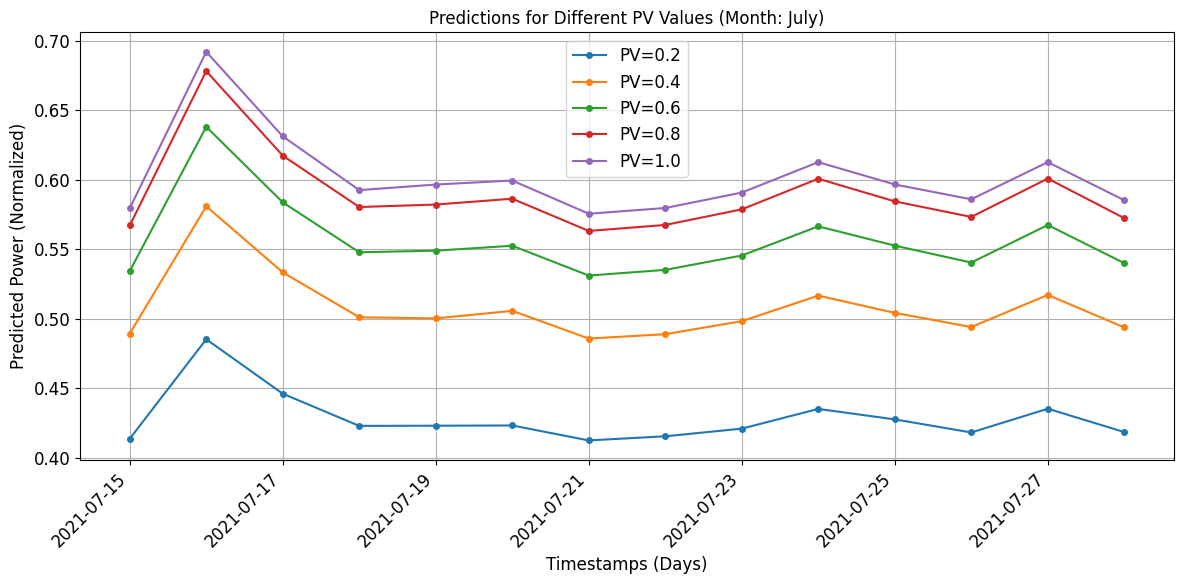

In [25]:
pv_values = [0.2, 0.4, 0.6, 0.8, 1.0]
model_names = ["02","04", "06", "08","10"]
models = {}

# initializing each trained model
for pv, model_name in zip(pv_values, model_names):
    model = simpleLSTM(n_input_features=5, num_layers=4) 
    model.load_state_dict(torch.load(f'./saved_runs/trained_pv_models/best_valid_model{model_name}.pt', map_location=torch.device("cpu")))
    #model.eval()
    models[pv] = model  # pv value is key 

#getting the test data for one month
test_data = {}
timestamps_data = {}
for pv in pv_values:
    file_path = f'./saved_runs/with_pv{pv}/test0_data_scaled.csv' # test0 = July 
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, index_col=0)
        test_data[pv] = df.values  
        timestamps_data[pv] = pd.to_datetime(df.index, utc=True)

#prepare plot
fig, ax = plt.subplots(figsize=(12, 6))

# plotting and predicting the values
for pv in pv_values:
    model = models[pv]
    whole_sequence = test_data[pv]  
    timestamps = timestamps_data[pv]

    predictions = run_closed_loop(model, whole_sequence, lookback=lookback, future_prediction=steps2predict, use_positional_encoding= 'pv_const')
    
    visualization_idx_start = 0
    visualization_idx_stop = visualization_idx_start + 96 * 14  # 14 days (96 timestamps each day)
    predictions_to_plot = predictions[visualization_idx_start:visualization_idx_stop]

    # extracting timestamp and grouping to days
    timestamps_for_plot = timestamps[:len(predictions_to_plot)]
    daily_timestamps = timestamps_for_plot.date  

    # grouping for each day and mean of the predictions for each day
    daily_predictions = []
    for day in pd.unique(daily_timestamps):
        daily_predictions.append(np.mean(predictions_to_plot[daily_timestamps == day]))  # taking the mean of each day

    #plotting
    ax.plot(pd.to_datetime(pd.unique(daily_timestamps)), daily_predictions, label=f'PV={pv}', marker='o', linestyle='-', markersize=4)

# labels and legend
ax.set_xlabel("Timestamps (Days)")
ax.set_ylabel("Predicted Power (Normalized)")
ax.set_title("Predictions for Different PV Values (Month: July)")
ax.legend()
ax.grid()

# making it more beautiul (hopefully)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()